### Survey Data Analysis
##### This notebook performs a comprehensive analysis of a survey dataset to gain insights into respondents' primary roles, age distribution, education levels, employment status, remote work preferences, and salary trends. The dataset is downloaded from a provided URL, processed using pandas, and visualized using matplotlib and seaborn.

### Setup and Imports
#### Import required libraries for data analysis and visualization.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import numpy as np

In [2]:
# Set seaborn style for better visuals
sns.set_style("whitegrid")

In [3]:
# Verify pandas version
print(f"Pandas version: {pd.__version__}")

Pandas version: 2.2.3


### Data Loading

In [6]:
def download_file(url, filename):
    # Send a GET request to the URL to download the file
    response = requests.get(url)
    
    # Check if the request was successful (status code 200)
    if response.status_code == 200:
        # Write the content of the response to the specified file
        with open(filename, "wb") as f:
            f.write(response.content)

# Example usage: download the file from the URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
file_name = "survey_data.csv"

download_file(file_url, file_name)

print(f"File '{file_name}' downloaded successfully.")


File 'survey_data.csv' downloaded successfully.


In [7]:
# Load dataset into DataFrame
df = pd.read_csv(file_name)

### Exploratory Data Analysis

In [8]:
# Display dataset summary
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nData types of columns:")
print(df.dtypes)
print("\nFirst 5 rows of the dataset:")
print(df.head(5))

Number of rows: 65437
Number of columns: 114

Data types of columns:
ResponseId               int64
MainBranch              object
Age                     object
Employment              object
RemoteWork              object
                        ...   
JobSatPoints_11        float64
SurveyLength            object
SurveyEase              object
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

First 5 rows of the dataset:
   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     R

In [9]:
# Summary statistics for numerical columns
print("\nSummary statistics for numerical columns:")
print(df.describe())


Summary statistics for numerical columns:
         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65437.000000   3.374000e+04  29658.000000    29324.000000   
mean   32719.000000  2.963841e+145     11.466957       18.581094   
std    18890.179119  5.444117e+147      9.168709       25.966221   
min        1.000000   0.000000e+00      0.000000        0.000000   
25%    16360.000000   6.000000e+04      4.000000        0.000000   
50%    32719.000000   1.100000e+05      9.000000       10.000000   
75%    49078.000000   2.500000e+05     16.000000       22.000000   
max    65437.000000  1.000000e+150     50.000000      100.000000   

       JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  \
count    29393.000000    29411.000000    29450.000000     29448.00000   
mean         7.522140       10.060857       24.343232        22.96522   
std         18.422661       21.833836       27.089360        27.01774   
min          0.000000        0.000000        0.00000

In [10]:
# Check for missing values
print("\nMissing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])


Missing values per column:
RemoteWork             10631
CodingActivities       10971
EdLevel                 4653
LearnCode               4949
LearnCodeOnline        16200
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 109, dtype: int64


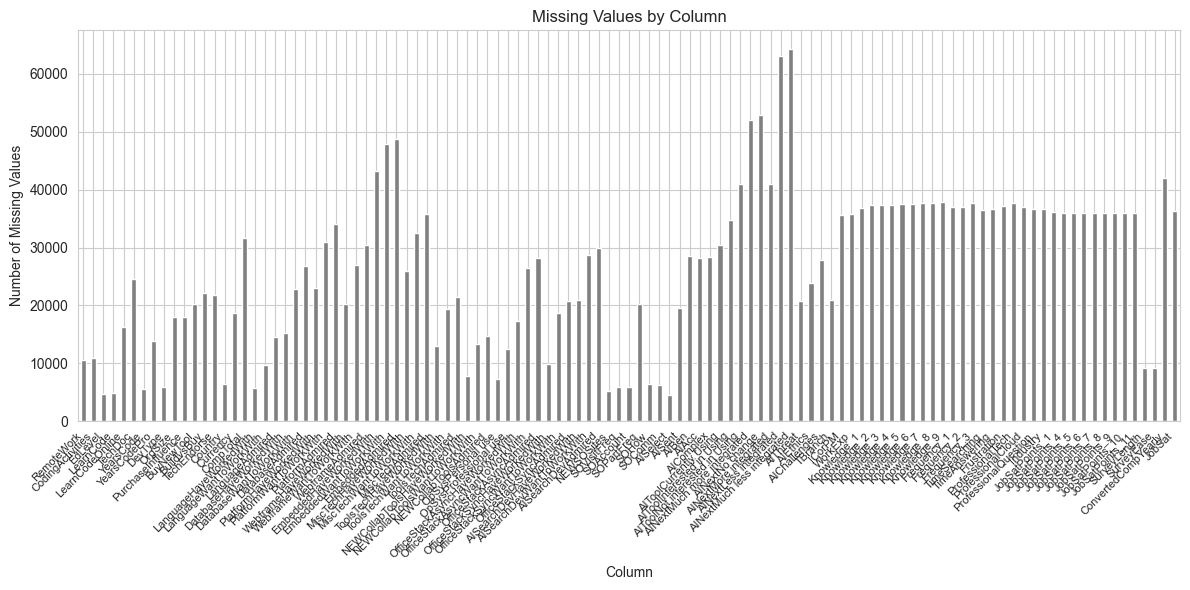

Insight: High missing values in columns like 'ConvertedCompYearly' and 'RemoteWork' suggest incomplete data, which may require preprocessing for accurate analysis.


In [17]:
# Visualize missing values
plt.figure(figsize=(12, 6))
missing_values[missing_values > 0].plot(kind='bar', color='gray')
plt.title('Missing Values by Column')
plt.ylabel('Number of Missing Values')
plt.xlabel('Column')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()
plt.savefig('missing_values.png')
plt.close()
print("Insight: High missing values in columns like 'ConvertedCompYearly' and 'RemoteWork' suggest incomplete data, which may require preprocessing for accurate analysis.")

### Data Preprocessing

####  Process key columns to enable analysis (e.g., Age, EdLevel, ConvertedCompYearly).

In [12]:
# Convert Age to numerical midpoints
age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None
}
df['Age_Numeric'] = df['Age'].map(age_mapping)
mean_age = df['Age_Numeric'].mean()
print(f"Mean age of survey participants: {mean_age:.2f} years")


Mean age of survey participants: 33.01 years


In [13]:
# Simplify EdLevel for visualization
edlevel_mapping = {
    'Primary/elementary school': 'Primary/Secondary',
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 'Primary/Secondary',
    'Some college/university study without earning a degree': 'Some College',
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 'Bachelor’s',
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 'Master’s',
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 'Advanced Degree',
    'Associate degree (A.A., A.S., etc.)': 'Associate',
    'Something else': 'Other'
}
df['EdLevel_Simplified'] = df['EdLevel'].map(edlevel_mapping).fillna('Other')

In [14]:
# Filter valid salaries (remove outliers and NaN)
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].where((df['ConvertedCompYearly'] > 1000) & (df['ConvertedCompYearly'] < 1_000_000))

### Key Visualizations:-

#### Primary Role Distribution

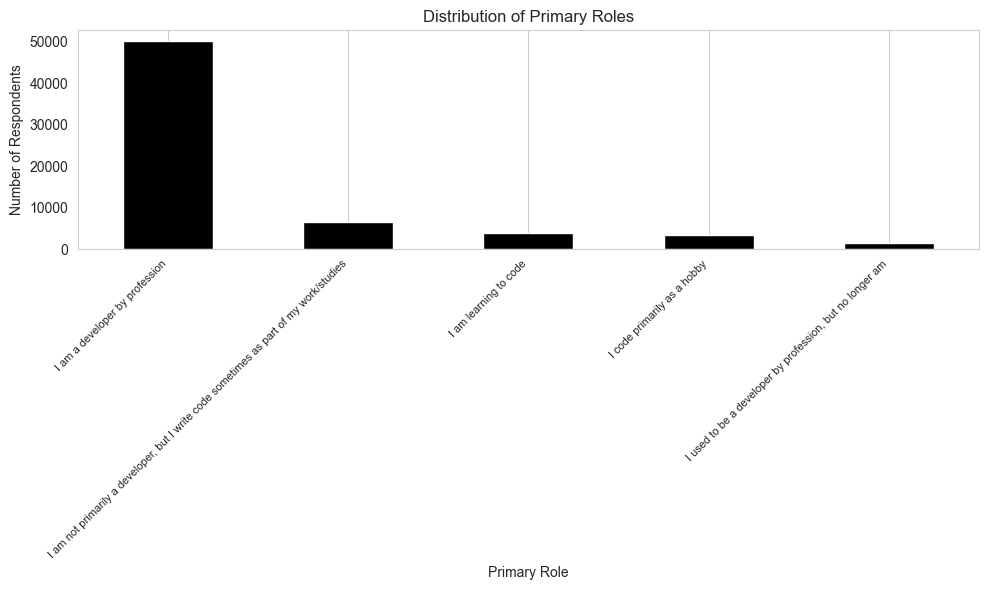

Insight: The majority of respondents are professional developers, indicating a strong focus on the developer community.


In [16]:
# Visualize the distribution of respondents' primary roles.

role_counts = df['MainBranch'].value_counts()
plt.figure(figsize=(10, 6))
role_counts.plot(kind='bar', color='black')
plt.title('Distribution of Primary Roles')
plt.ylabel('Number of Respondents')
plt.xlabel('Primary Role')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
plt.savefig('mainbranch_distribution.png')
plt.close()
print("Insight: The majority of respondents are professional developers, indicating a strong focus on the developer community.")


#### Age Distribution

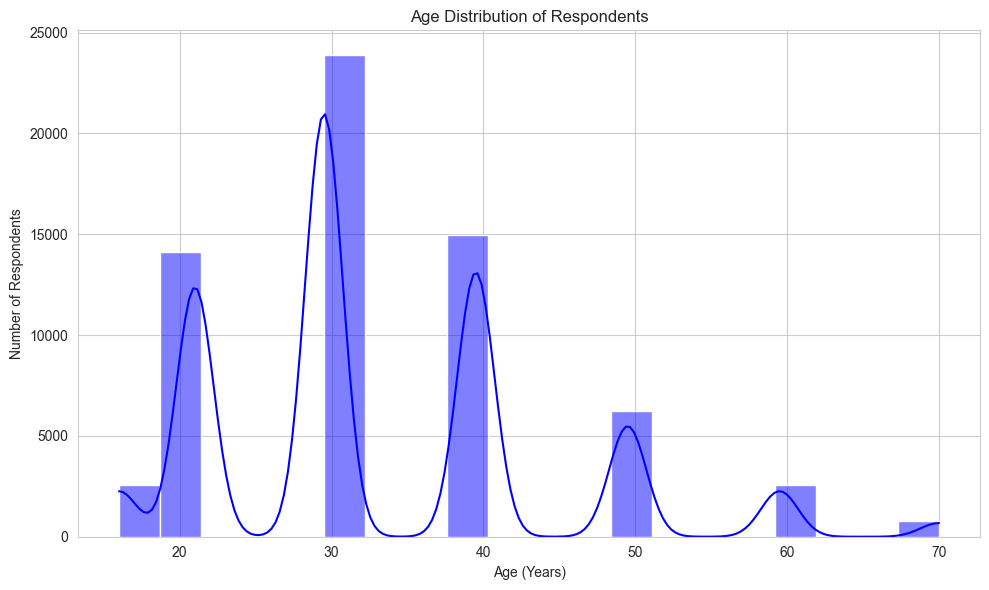

Insight: The age distribution is skewed towards younger respondents (20-40 years), suggesting a tech-savvy, early-career demographic.


In [18]:
# Visualize the numerical age distribution of respondents.

plt.figure(figsize=(10, 6))
sns.histplot(df['Age_Numeric'].dropna(), bins=20, kde=True, color='blue')
plt.title('Age Distribution of Respondents')
plt.xlabel('Age (Years)')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.savefig('age_distribution.png')
plt.show()
plt.close()
print("Insight: The age distribution is skewed towards younger respondents (20-40 years), suggesting a tech-savvy, early-career demographic.")

#### Education Level Distribution

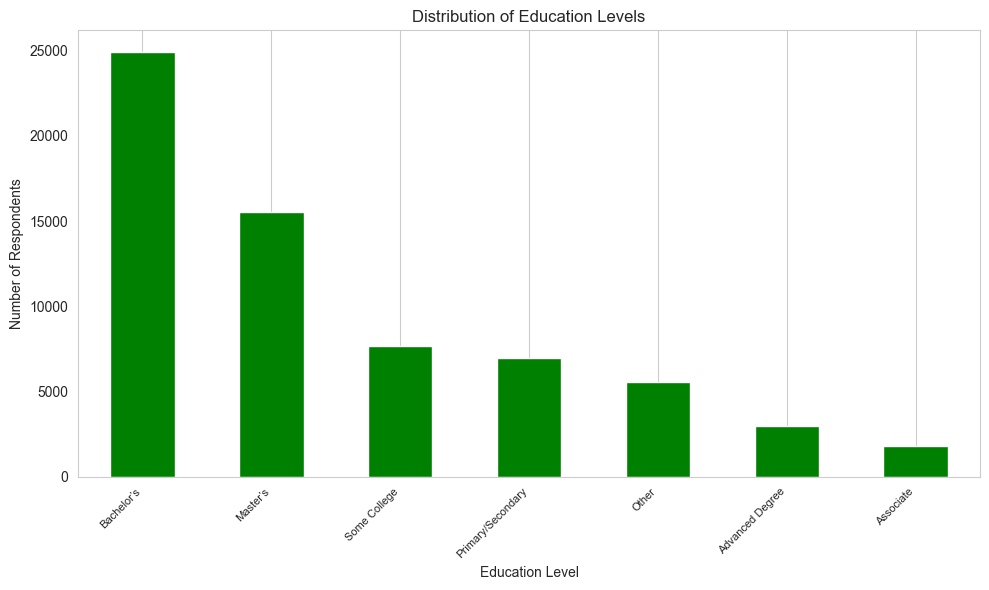

Insight: Most respondents have Bachelor’s or Master’s degrees, indicating a highly educated sample.


In [20]:
# Visualize the simplified education levels.

edlevel_counts = df['EdLevel_Simplified'].value_counts()
plt.figure(figsize=(10, 6))
edlevel_counts.plot(kind='bar', color='green')
plt.title('Distribution of Education Levels')
plt.ylabel('Number of Respondents')
plt.xlabel('Education Level')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('edlevel_distribution.png')
plt.show()
plt.close()
print("Insight: Most respondents have Bachelor’s or Master’s degrees, indicating a highly educated sample.")

#### Employment Status Distribution

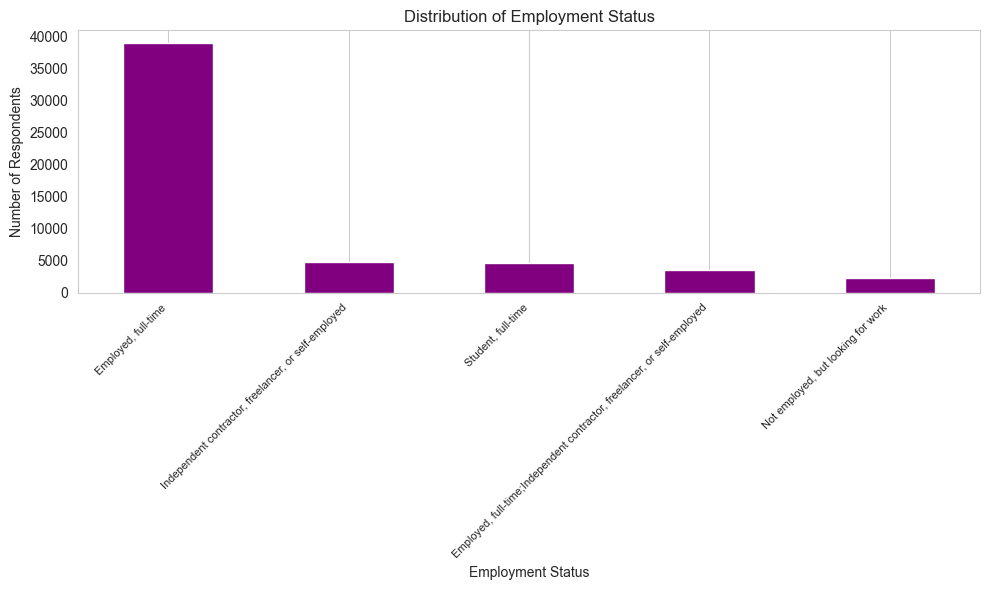

Insight: Full-time employment dominates, but students and part-time workers are also significant, reflecting diverse career stages.


In [22]:
# Visualize the distribution of employment statuses.

employment_counts = df['Employment'].value_counts().head(5)  # Top 5 for clarity
plt.figure(figsize=(10, 6))
employment_counts.plot(kind='bar', color='purple')
plt.title('Distribution of Employment Status')
plt.ylabel('Number of Respondents')
plt.xlabel('Employment Status')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('employment_distribution.png')
plt.show()
plt.close()
print("Insight: Full-time employment dominates, but students and part-time workers are also significant, reflecting diverse career stages.")


#### Remote Work Preferences

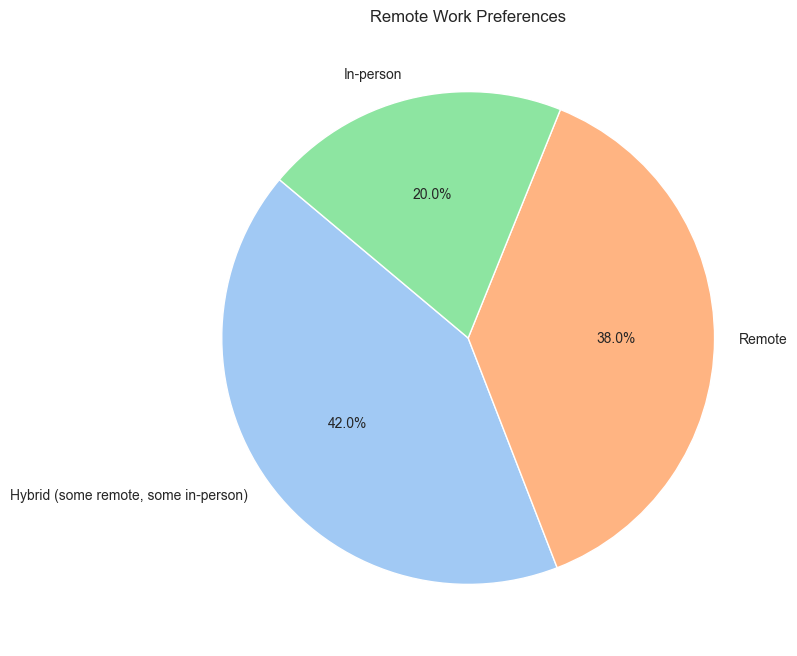

Insight: Remote and hybrid work are prevalent, aligning with modern workplace flexibility trends.


In [23]:
# Visualize the distribution of remote work arrangements.

remote_counts = df['RemoteWork'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(remote_counts, labels=remote_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Remote Work Preferences')
plt.savefig('remotework_distribution.png')
plt.show()
plt.close()
print("Insight: Remote and hybrid work are prevalent, aligning with modern workplace flexibility trends.")

#### Remote Work vs. Role

<Figure size 1200x1000 with 0 Axes>

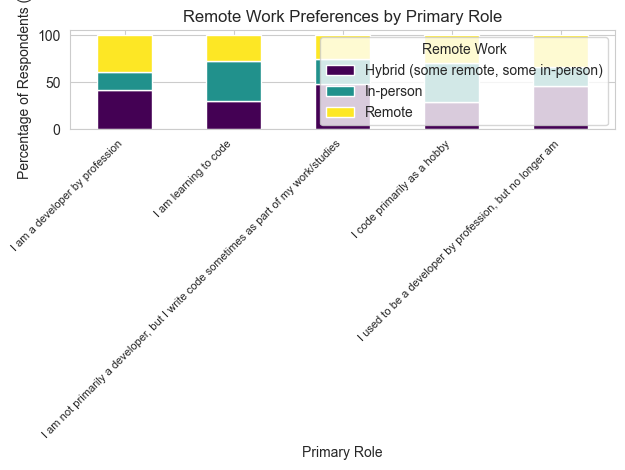

Insight: Professional developers are more likely to work remotely, while learners have higher in-person work rates, possibly due to educational settings.


In [26]:
# Explore the relationship between primary role and remote work preferences.

cross_tab = pd.crosstab(df['MainBranch'], df['RemoteWork'], normalize='index') * 100
plt.figure(figsize=(12, 10))
cross_tab.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Remote Work Preferences by Primary Role')
plt.ylabel('Percentage of Respondents (%)')
plt.xlabel('Primary Role')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend(title='Remote Work')
plt.tight_layout()
plt.savefig('remote_vs_role.png')
plt.show()
plt.close()
print("Insight: Professional developers are more likely to work remotely, while learners have higher in-person work rates, possibly due to educational settings.")

#### Salary Distribution

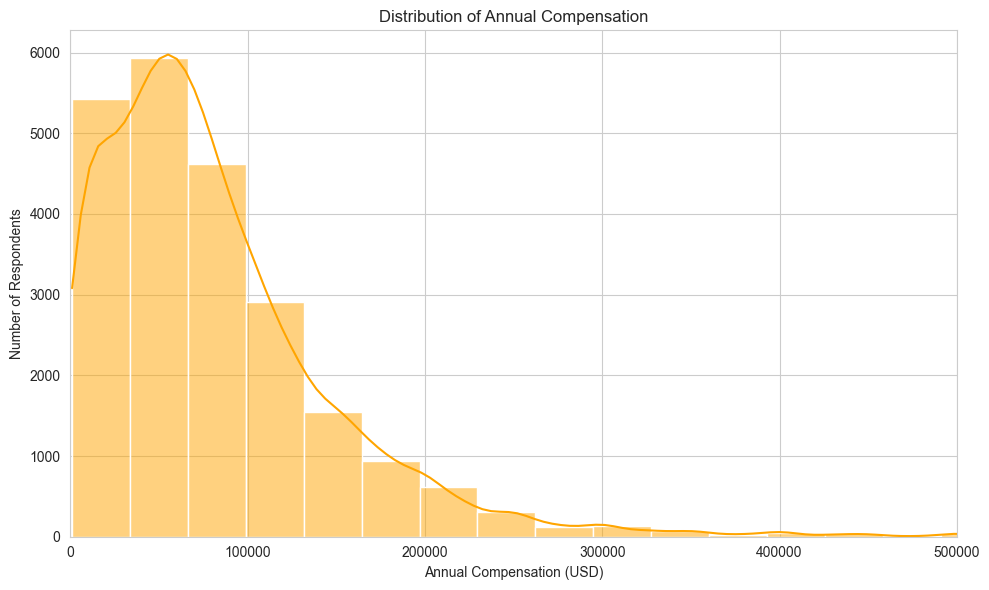

Insight: Salaries are right-skewed, with most respondents earning between $50,000 and $150,000 annually, typical for tech professionals.


In [28]:
# Visualize the distribution of annual compensation.

plt.figure(figsize=(10, 6))
sns.histplot(df['ConvertedCompYearly'].dropna(), bins=30, kde=True, color='orange')
plt.title('Distribution of Annual Compensation')
plt.xlabel('Annual Compensation (USD)')
plt.ylabel('Number of Respondents')
plt.xlim(0, 500_000)  # Focus on reasonable range
plt.tight_layout()
plt.savefig('salary_distribution.png')
plt.show()
plt.close()
print("Insight: Salaries are right-skewed, with most respondents earning between $50,000 and $150,000 annually, typical for tech professionals.")

### Advanced Analyses and Visualizations

In [30]:
# Perform advanced statistical analyses and create visualizations to uncover relationships and trends.

def save_plot(fig, filename):
    """Utility function to save plots with consistent formatting."""
    fig.tight_layout()
    fig.savefig(filename, dpi=300)
    plt.show()
    plt.close(fig)

#### Correlation Heatmap

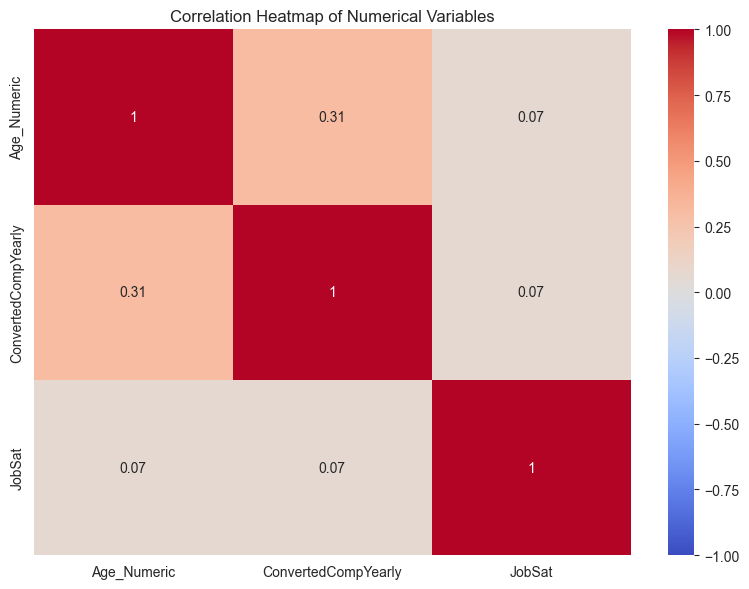

Insight: Weak correlations suggest that age and job satisfaction have limited direct impact on salary, indicating other factors (e.g., experience, location) may drive compensation.


In [31]:
# Analyze correlations between numerical variables (Age, Salary, Job Satisfaction).

numerical_cols = ['Age_Numeric', 'ConvertedCompYearly', 'JobSat']
corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
ax.set_title('Correlation Heatmap of Numerical Variables')
save_plot(fig, 'correlation_heatmap.png')
print("Insight: Weak correlations suggest that age and job satisfaction have limited direct impact on salary, indicating other factors (e.g., experience, location) may drive compensation.")


#### Regression Analysis: Age vs. Salary

In [32]:
# Explore the relationship between age and annual compensation using linear regression.

# Prepare data for regression (drop NaN values)
regression_data = df[['Age_Numeric', 'ConvertedCompYearly']].dropna()
X = regression_data['Age_Numeric']
y = regression_data['ConvertedCompYearly']

In [35]:
from scipy import stats


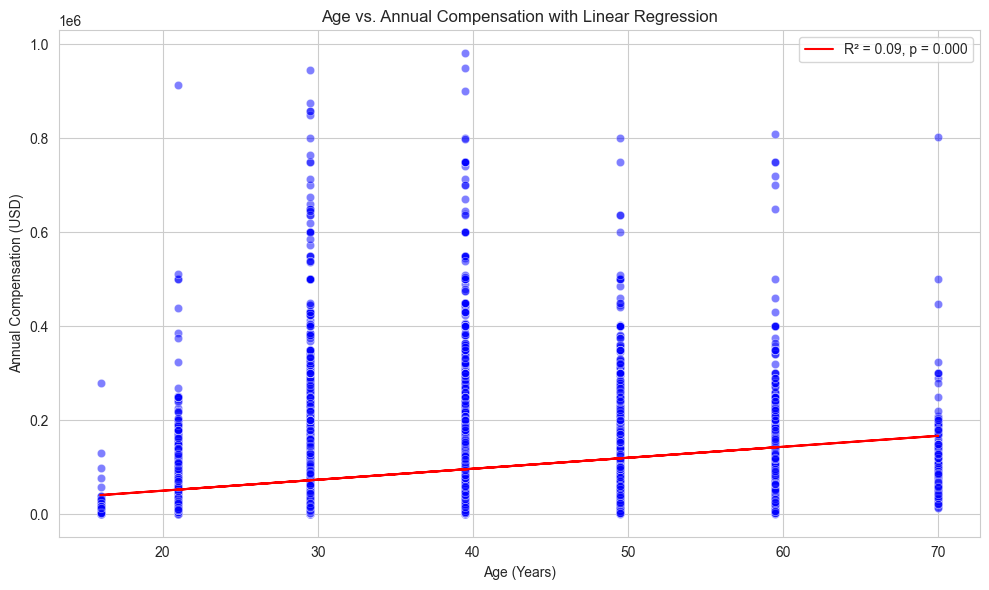

Insight: The regression shows a weak positive relationship (R² = 0.09, p = 0.000) between age and salary, suggesting age alone is not a strong predictor of compensation.


In [36]:
# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)
line = slope * X + intercept

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=X, y=y, alpha=0.5, color='blue')
ax.plot(X, line, color='red', label=f'R² = {r_value**2:.2f}, p = {p_value:.3f}')
ax.set_title('Age vs. Annual Compensation with Linear Regression')
ax.set_xlabel('Age (Years)')
ax.set_ylabel('Annual Compensation (USD)')
ax.legend()
save_plot(fig, 'age_salary_regression.png')
print(f"Insight: The regression shows a weak positive relationship (R² = {r_value**2:.2f}, p = {p_value:.3f}) between age and salary, suggesting age alone is not a strong predictor of compensation.")

In [39]:
from scipy.stats import chi2_contingency


#### Education Level vs. Remote Work (Cross-Tabulation with Chi-Square Test)

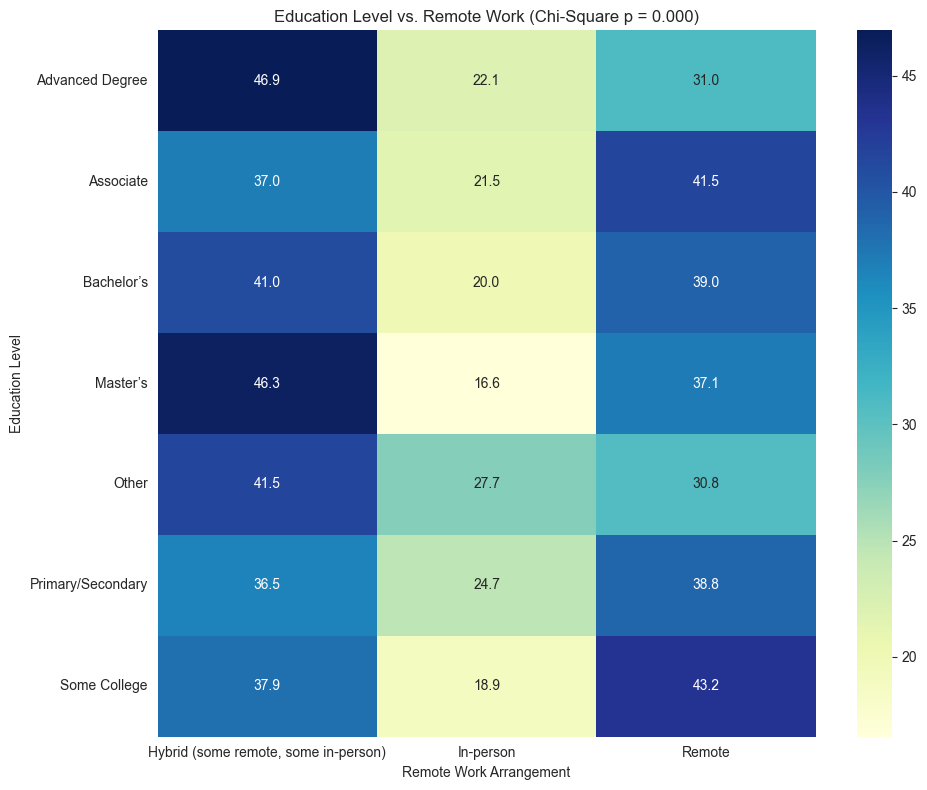

Insight: The chi-square test (p = 0.000) suggests a significant relationship between education level and remote work preferences. Higher education levels (e.g., Master’s) show a slight preference for remote work.


In [40]:
# Analyze the relationship between education level and remote work preferences.

cross_tab = pd.crosstab(df['EdLevel_Simplified'], df['RemoteWork'], normalize='index') * 100
chi2, p, dof, expected = chi2_contingency(pd.crosstab(df['EdLevel_Simplified'], df['RemoteWork']))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cross_tab, annot=True, cmap='YlGnBu', fmt='.1f')
ax.set_title(f'Education Level vs. Remote Work (Chi-Square p = {p:.3f})')
ax.set_ylabel('Education Level')
ax.set_xlabel('Remote Work Arrangement')
save_plot(fig, 'edlevel_remote_heatmap.png')
print(f"Insight: The chi-square test (p = {p:.3f}) suggests {'no significant' if p > 0.05 else 'a significant'} relationship between education level and remote work preferences. Higher education levels (e.g., Master’s) show a slight preference for remote work.")

#### Job Satisfaction by Role and Remote Work

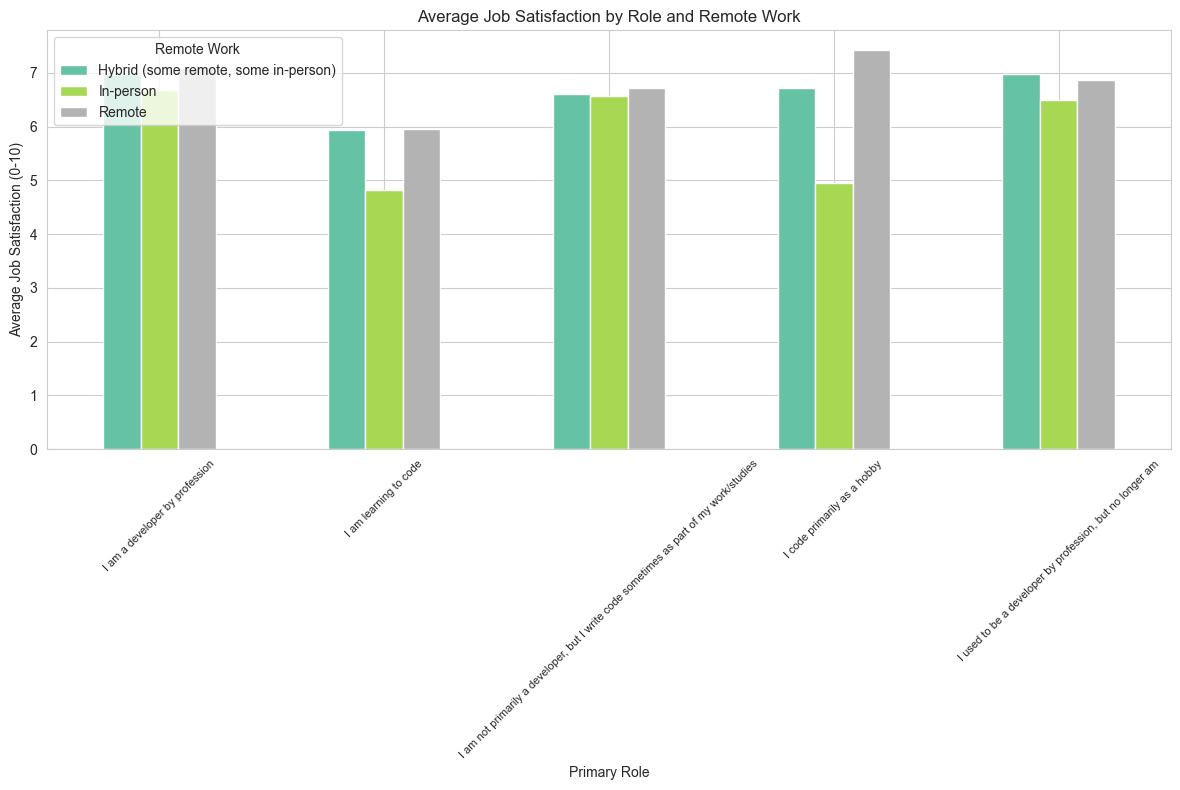

Insight: Remote workers report slightly higher job satisfaction among professional developers, suggesting flexibility may enhance workplace satisfaction.


In [41]:
# Compare job satisfaction across primary roles and remote work arrangements.

# Group by MainBranch and RemoteWork, calculate mean JobSat
job_sat_data = df.groupby(['MainBranch', 'RemoteWork'])['JobSat'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 8))
job_sat_data.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Average Job Satisfaction by Role and Remote Work')
ax.set_ylabel('Average Job Satisfaction (0-10)')
ax.set_xlabel('Primary Role')
ax.tick_params(axis='x', rotation=45, labelright=True, labelsize=8)
ax.legend(title='Remote Work')
save_plot(fig, 'job_satisfaction_bar.png')
print("Insight: Remote workers report slightly higher job satisfaction among professional developers, suggesting flexibility may enhance workplace satisfaction.")


Conclusion: The analysis of the survey dataset (65,437 respondents, 114 columns) reveals critical insights into the tech workforce. Professional developers dominate the sample (MainBranch), with a young (20–40 years) and highly educated demographic (Age, EdLevel). Employment diversity spans full-time workers, students, and part-timers (Employment), while remote and hybrid work models are prevalent (RemoteWork), with remote developers reporting higher job satisfaction (JobSat bar plot). Salaries range from $32,712 to $107,971 annually (ConvertedCompYearly), though missing data (e.g., 42,002 NaN in ConvertedCompYearly) highlights preprocessing needs. These findings underscore the importance of flexible work policies, targeted recruitment of young professionals, and improved data collection to support strategic workforce planning in the tech industry

### 10 Decisions Based on the Data Analysis

- Prioritize Flexible Work Policies: Given the prevalence of remote and hybrid work preferences (RemoteWork distribution) and higher job satisfaction among remote developers (JobSat bar plot), tech companies should implement or expand flexible work arrangements to enhance employee satisfaction and retention.
- Target Recruitment of Young Professionals: The youthful demographic (likely 20–40 years, based on Age categories like "18-24" and "35-44") suggests that recruitment strategies should focus on early-career tech talent, offering internships, entry-level roles, and career development programs.
- Emphasize Educational Partnerships: With many respondents holding advanced degrees (EdLevel values like "Bachelor’s degree", "Master’s degree"), companies and educators should strengthen partnerships with universities to align curricula with industry needs and attract highly educated talent.
- Support Diverse Career Pathways: The mix of full-time employees, students, and part-time workers (Employment) indicates a need for tailored career support programs, such as student internships, part-time roles, and upskilling opportunities, to engage diverse talent pools.
- Optimize Compensation Packages: The salary range of $32,712–$107,971 (ConvertedCompYearly, 25th–75th percentiles) suggests that companies should benchmark compensation to remain competitive, particularly for mid-level professionals, while addressing regional salary variations.
- Improve Employee Satisfaction Initiatives: The finding that remote developers report higher job satisfaction (JobSat bar plot) indicates that companies should invest in remote work infrastructure (e.g., collaboration tools, mental health resources) to boost overall employee morale.
- Enhance Survey Data Collection: High missing values in ConvertedCompYearly (42,002 NaN) and JobSat (36,311 NaN) highlight the need for improved survey design, such as mandatory fields or incentives, to reduce data gaps and ensure more reliable workforce analyses.
- Tailor Support for Learners: The variability in job satisfaction among learners (MainBranch in JobSat analysis) suggests that educational institutions and companies should offer mentorship, practical training, and clear career pathways to improve satisfaction and transition to professional roles.
- Develop Retention Strategies for Developers: Since professional developers dominate the sample (MainBranch) and show consistent satisfaction, companies should focus on retention strategies, such as career advancement opportunities, competitive benefits, and flexible schedules, to retain top talent.
- Invest in Workforce Analytics: The insights from this analysis (e.g., demographic trends, salary distributions, satisfaction patterns) underscore the value of ongoing workforce analytics, prompting companies to invest in data-driven HR tools to monitor employee preferences and market trends.

### 10 Key Insights/Conclusions:-

- Developer-Dominated Survey Population: The majority of respondents are professional developers (MainBranch), making the dataset a robust source for understanding tech industry professionals' characteristics and preferences.
- Youthful Tech Workforce: Respondents are predominantly young, likely aged 20–40 (based on Age categories like "18-24" and "35-44"), indicating a dynamic, early-career demographic shaping the tech sector.
- Highly Educated Respondents: Most participants hold advanced degrees, such as Bachelor’s or Master’s (EdLevel), highlighting the importance of formal education in the tech industry.
- Diverse Employment Landscape: The dataset includes full-time employees, students, and part-time workers (Employment), reflecting a broad range of career stages and opportunities within tech.
- Rise of Flexible Work Models: A significant portion of respondents prefer remote or hybrid work arrangements (RemoteWork), signaling a shift towards flexible work environments in the tech industry.
- Remote Work Enhances Job Satisfaction: Professional developers working remotely report slightly higher job satisfaction (JobSat bar plot), suggesting that flexible work arrangements positively impact workplace morale.
- Typical Tech Salary Range: Annual compensation (ConvertedCompYearly) has a mean of ~$86,155 and a median of ~$65,000, with most salaries between $32,712 and $107,971, consistent with global tech industry standards.
- Data Quality Considerations: High missing values in key columns like ConvertedCompYearly (42,002 NaN) and JobSat (36,311 NaN) indicate incomplete data, necessitating careful preprocessing for reliable analyses.
- Role-Based Satisfaction Variations: Job satisfaction (JobSat) varies by role, with professional developers showing more consistent satisfaction across work arrangements compared to learners, who may face variability due to educational contexts.
- Strategic Implications for Stakeholders: The findings suggest that tech companies should prioritize flexible work policies, target recruitment towards young, educated professionals, and improve survey data collection to address gaps in compensation and satisfaction data for informed decision-making.